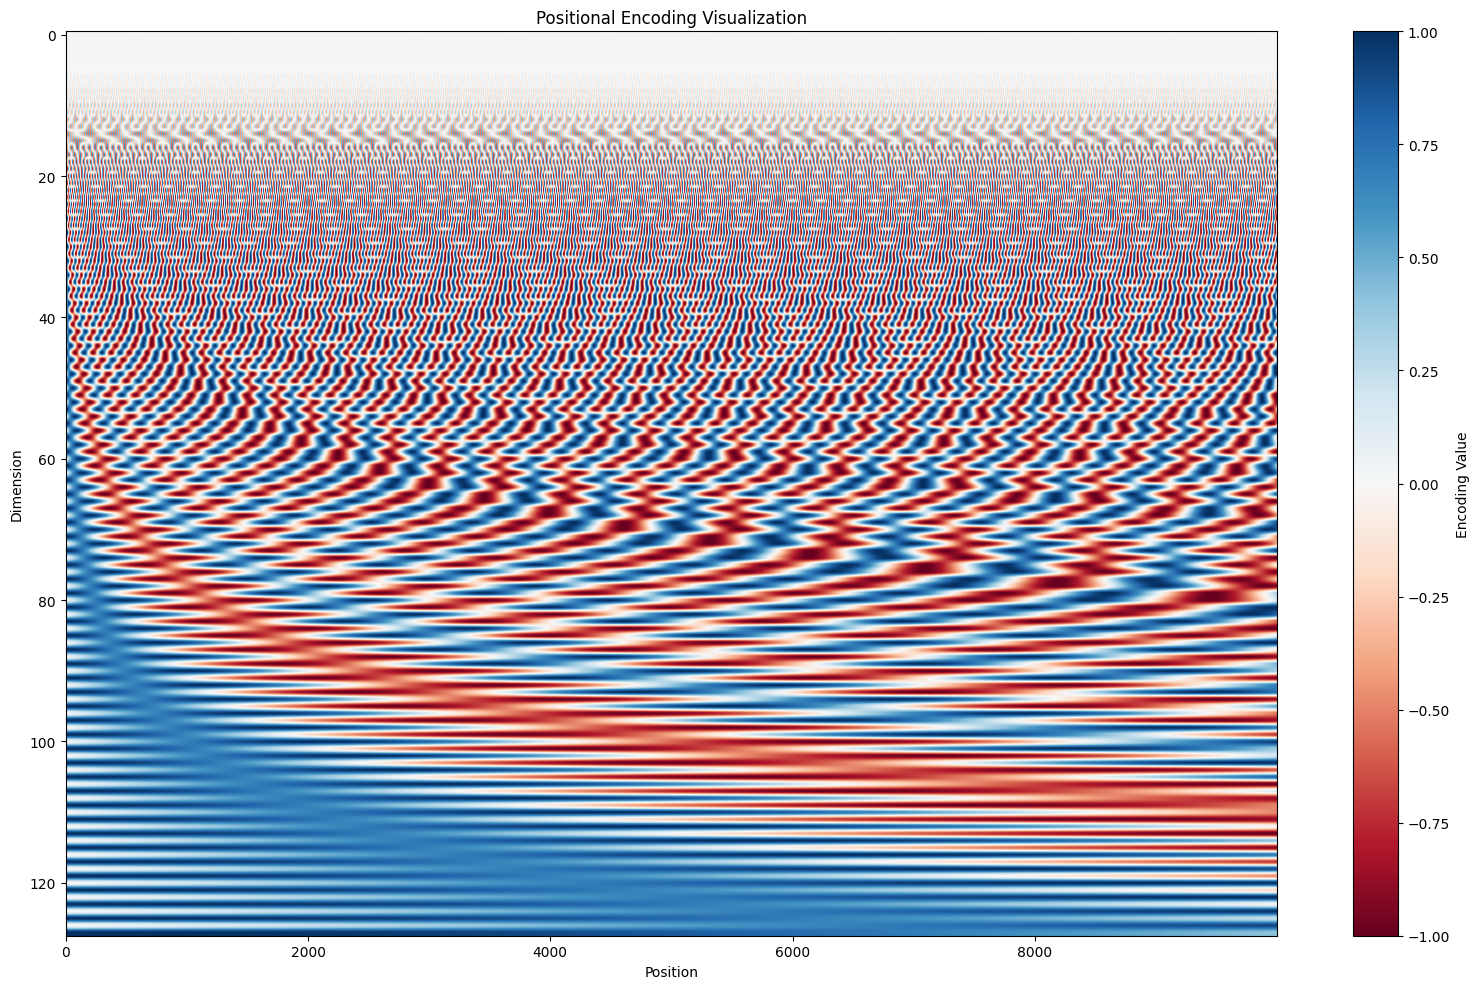

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def pos_encoding(seq_len: int, d_model: int):
    if seq_len == 0 or d_model <= 0: return -1
    pe = np.zeros((seq_len, d_model))
    positions = np.arange(0, seq_len)
    positions = positions[:, np.newaxis]

    factor = -(np.log(10000.0) / d_model) * np.arange(0, d_model, 2)
    factor = np.exp(factor)

    pe[:, 0::2] = np.sin(positions * factor)
    pe[:, 1::2] = np.cos(positions * factor)
    return pe

def plot_pos_encoding(pe):
    # Visualize the positional encoding
    plt.figure(figsize=(16, 10))
    plt.imshow(pe.T, cmap='RdBu', aspect='auto')
    # plt.imshow(pe, cmap='RdBu', aspect='auto')
    plt.colorbar(label='Encoding Value')
    plt.xlabel('Position')
    plt.ylabel('Dimension')
    plt.title('Positional Encoding Visualization')
    plt.tight_layout()
    plt.show()

# pe = pos_encoding(100, 10)
pe = pos_encoding(int(10000), 128)
plot_pos_encoding(pe)

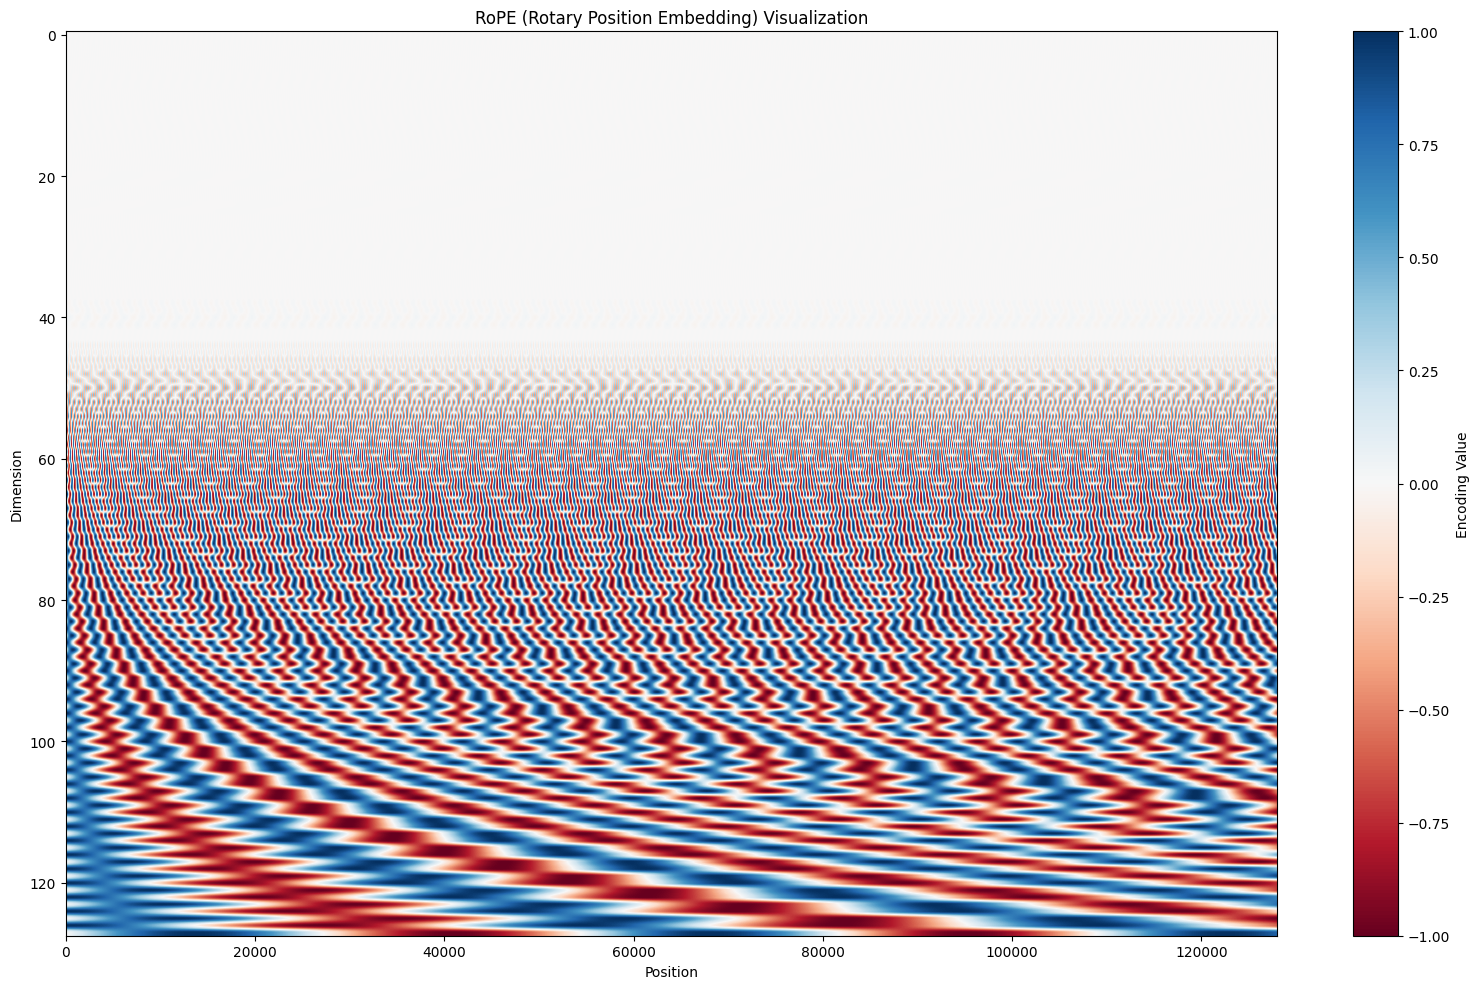

In [63]:
import numpy as np
import matplotlib.pyplot as plt

def rope_encoding(seq_len: int, d_model: int):
    if seq_len == 0 or d_model <= 0: return -1
    
    # Create position indices
    positions = np.arange(seq_len)
    
    # Create frequency values for each dimension pair
    freqs = 1.0 / (10000 ** (np.arange(0, d_model, 2) / d_model))
    
    # Compute angles for each position and frequency
    angles = positions[:, np.newaxis] * freqs[np.newaxis, :]
    
    # Create cos and sin components
    cos_vals = np.cos(angles)
    sin_vals = np.sin(angles)
    
    # Interleave cos and sin values
    rope = np.zeros((seq_len, d_model))
    rope[:, 0::2] = cos_vals
    rope[:, 1::2] = sin_vals
    
    return rope

def plot_rope_encoding(rope):
    # Visualize the RoPE encoding
    plt.figure(figsize=(16, 10))
    plt.imshow(rope.T, cmap='RdBu', aspect='auto')
    plt.colorbar(label='Encoding Value')
    plt.xlabel('Position')
    plt.ylabel('Dimension')
    plt.title('RoPE (Rotary Position Embedding) Visualization')
    plt.tight_layout()
    plt.show()

# rope = rope_encoding(100, 10)
rope = rope_encoding(int(128e3), 128)
plot_rope_encoding(rope)